# Proyecto 1 — Predicción del precio horario de la energía en Guatemala

Queremos predecir el precio de oportunidad de la energía (USD/MWh) hora por hora para 2025, usando como historia 2023 y 2024. Lo tratamos como un problema de regresión.

In [3]:
import re
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

## 1. Carga, limpieza y transformación de datos


In [4]:
pd.read_excel("data/Precios2023.xls", sheet_name="POE (Anual)", header=None, nrows=6, engine="xlrd")

,0,1,2
0,Administrador del Mercado Mayorista de Guatemala,NaN,NaN
1,Precios de Oportunidad de la Energía,NaN,NaN
2,Año 2023,NaN,NaN
3,Día,hora,USD/MWH
4,2023-01-01 00:00:00,0,74.2314
5,2023-01-01 00:00:00,1,74.2314


Las primeras 3 filas son encabezado y la fila 3 trae los nombres de columna: Día, hora, USD/MWH. Por lo tanto, se ignoran estas filas y se continúa hasta encontrar la data.

In [5]:
def leer_anio(anio):
    df = pd.read_excel(f"data/Precios{anio}.xls", sheet_name="POE (Anual)",
                       skiprows=3, engine="xlrd")
    df.columns = ["fecha", "hora", "precio"]  
    df["anio"] = anio
    return df

df = pd.concat([leer_anio(a) for a in [2023, 2024, 2025]], ignore_index=True)
print(df.shape)
df.head()

(26304, 4)


,fecha,hora,precio,anio
0,2023-01-01,0,74.2314,2023
1,2023-01-01,1,74.2314,2023
2,2023-01-01,2,59.0752,2023
3,2023-01-01,3,59.0752,2023
4,2023-01-01,4,80.9615,2023


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26304 entries, 0 to 26303
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   fecha   26304 non-null  datetime64[ns]
 1   hora    26304 non-null  int64         
 2   precio  26304 non-null  object        
 3   anio    26304 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 822.1+ KB


La fecha ya viene como datetime, bien. Pero el precio salió como object en vez de número, o sea que hay texto metido en esa columna. Se debe buscar que provoca que no sea el datatype correcto.

In [7]:
malos = df[pd.to_numeric(df["precio"], errors="coerce").isna()]
malos[["anio", "fecha", "hora", "precio"]]

,anio,fecha,hora,precio
2777,2023,2023-04-26,17,167.9951l
6632,2023,2023-10-04,8,104.2607'
6786,2023,2023-10-10,18,142.0377s
7043,2023,2023-10-21,11,156.9681a
8942,2024,2024-01-08,14,d
9097,2024,2024-01-15,1,69.038.0
14217,2024,2024-08-15,9,86.6421p
17638,2025,2025-01-04,22,2.1302.wq
17720,2025,2025-01-08,8,87.5625.3


In [8]:
def a_numero(x):
    if isinstance(x, (int, float)):
        return float(x)
    s = re.sub(r"[^0-9.]", "", str(x))      
    if s.count(".") > 1:                     
        p = s.find(".")
        s = s[:p+1] + s[p+1:].replace(".", "")
    return float(s) if s not in ("", ".") else np.nan

df["precio"] = df["precio"].apply(a_numero)
print("precios que quedaron como NaN:", df["precio"].isna().sum())   

precios que quedaron como NaN: 1


In [9]:
sorted(df["hora"].unique())

[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(220),
 np.int64(230),
 np.int64(2300)]

Aparecen 220, 230 y 2300, que no son horas válidas. Se necesita unicamente remover esos valores y reemplazarlos por los correctos.

In [10]:
df["hora"] = df["hora"].replace({220: 22, 230: 23, 2300: 23})
sorted(df["hora"].unique())   

[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23)]

armo la columna de fecha y hora, y recolecto información necesaria para el análisis como mes, día de la semana, si es fin de semana.

In [11]:
df["datetime"] = df["fecha"] + pd.to_timedelta(df["hora"], unit="h")
df = df.sort_values("datetime").reset_index(drop=True)

df["mes"] = df["datetime"].dt.month
df["dia_sem"] = df["datetime"].dt.dayofweek   
df["finde"] = df["dia_sem"] >= 5
df.head()

,fecha,hora,precio,anio,datetime,mes,dia_sem,finde
0,2023-01-01,0,74.2314,2023,2023-01-01 00:00:00,1,6,True
1,2023-01-01,1,74.2314,2023,2023-01-01 01:00:00,1,6,True
2,2023-01-01,2,59.0752,2023,2023-01-01 02:00:00,1,6,True
3,2023-01-01,3,59.0752,2023,2023-01-01 03:00:00,1,6,True
4,2023-01-01,4,80.9615,2023,2023-01-01 04:00:00,1,6,True


interpolo el número faltante que tiene la letra d usando un promedio con el número anterior y el número siguiente. 

In [12]:
print(df[df["precio"].isna()][["fecha", "hora", "precio"]])
df["precio"] = df["precio"].interpolate()
print("faltantes despues:", df["precio"].isna().sum())

          fecha  hora  precio
8942 2024-01-08    14     NaN
faltantes despues: 0


In [13]:
dias = df.groupby("fecha").size()
print("dias que NO tienen 24 horas:", (dias != 24).sum())
print("filas duplicadas (misma fecha y hora):", df.duplicated(["fecha", "hora"]).sum())


print(df.groupby("anio").size())

dias que NO tienen 24 horas: 0
filas duplicadas (misma fecha y hora): 0
anio
2023    8760
2024    8784
2025    8760
dtype: int64


### División de los datos

Les puse etiqueta a los datasets de entrenamiento y 2025 como prueba y no para entrenar.

In [14]:
train = df[df["anio"] < 2025].copy()
test_2025 = df[df["anio"] == 2025].copy()
print("entrenamiento (2023-2024):", len(train))
print("prueba (2025, reservado):", len(test_2025))

entrenamiento (2023-2024): 17544
prueba (2025, reservado): 8760


## 2. Análisis exploratorio del mercado

Descripción estadística de los precios.

In [15]:
train["precio"].describe().round(2)

count      17544.00
mean         284.21
std        12320.15
min            0.63
25%           76.43
50%          101.56
75%          132.10
max      1376899.00
Name: precio, dtype: float64

La media (284) está bastante por encima de la mediana (101.56) y el máximo supera el millón, así que hay unos valores altos que suben el promedio.

Para describir los patrones uso la mediana en lugar de la media, porque es menos sensible a esos valores extremos. Con la media, un outlier extremo en una hora bastaría para inflar el promedio de esa hora.

### Cómo evoluciona el precio en el tiempo

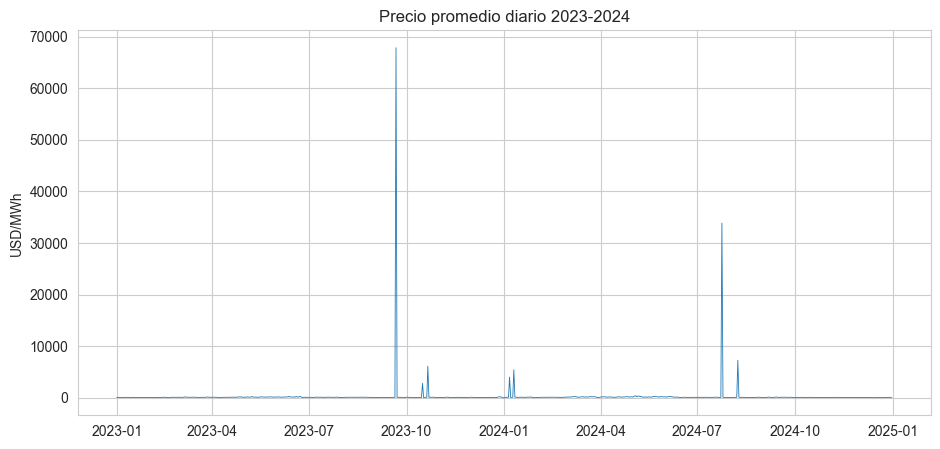

In [16]:
# precio promedio por dia
diario = train.set_index("datetime")["precio"].resample("D").mean()
plt.plot(diario.index, diario.values, lw=0.6)
plt.title("Precio promedio diario 2023-2024")
plt.ylabel("USD/MWh")
plt.show()

Como se puede observar, los picos mencionados alteran el promedio diario.

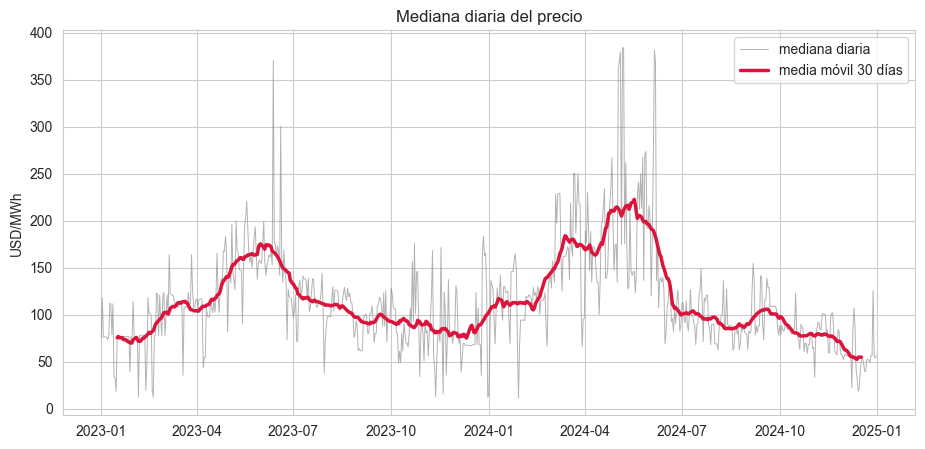

In [17]:
diario_med = train.set_index("datetime")["precio"].resample("D").median()
plt.plot(diario_med.index, diario_med.values, lw=0.7, color="gray", alpha=0.6, label="mediana diaria")
plt.plot(diario_med.index, diario_med.rolling(30, center=True).mean(), lw=2.5, color="crimson", label="media móvil 30 días")
plt.title("Mediana diaria del precio")
plt.ylabel("USD/MWh")
plt.legend()
plt.show()

Con la mediana se distingue mejor la forma. El precio sube entre marzo y junio y baja en la segunda mitad del año, así que parece tener un componente estacional. Se ve más claro en el gráfico por mes.

### Patrón por hora del día

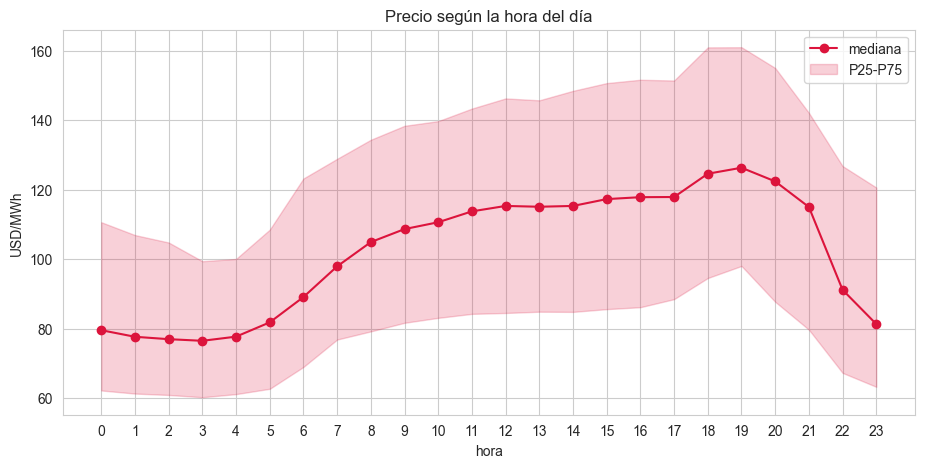

hora más barata: 3 | hora más cara: 19


In [18]:
por_hora = train.groupby("hora")["precio"].median()
q25 = train.groupby("hora")["precio"].quantile(0.25)
q75 = train.groupby("hora")["precio"].quantile(0.75)

plt.plot(por_hora.index, por_hora.values, "o-", color="crimson", label="mediana")
plt.fill_between(por_hora.index, q25, q75, alpha=0.2, color="crimson", label="P25-P75")
plt.xticks(range(24))
plt.xlabel("hora"); plt.ylabel("USD/MWh")
plt.title("Precio según la hora del día")
plt.legend()
plt.show()

print("hora más barata:", por_hora.idxmin(), "| hora más cara:", por_hora.idxmax())

El precio es más bajo de madrugada y alcanza su punto más alto en la tarde/noche. En las horas pico el área de P25-P75 también es más ancha, es decir que hay más variación de precio en esas horas.

### Patrón por día de la semana

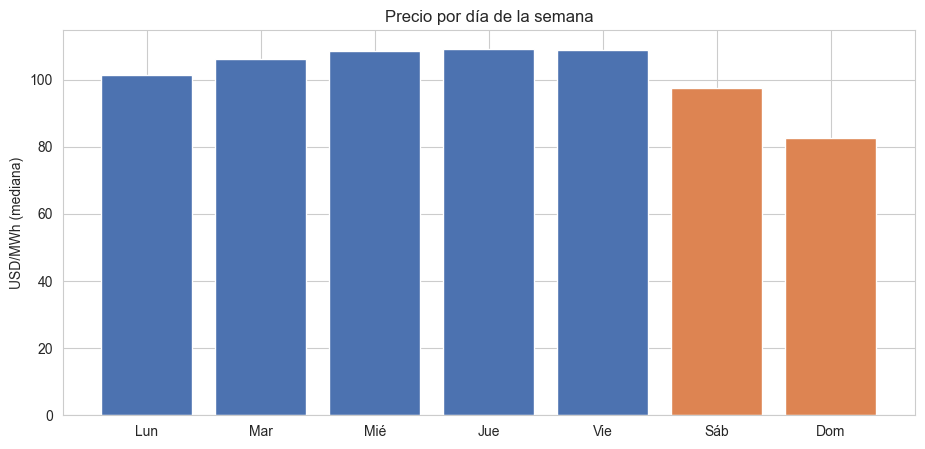

laboral: 108.2 | fin de semana: 89.4


In [19]:
dias_nom = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
por_dia = train.groupby("dia_sem")["precio"].median()

colores = ["#4C72B0"]*5 + ["#DD8452"]*2
plt.bar([dias_nom[i] for i in por_dia.index], por_dia.values, color=colores)
plt.ylabel("USD/MWh (mediana)")
plt.title("Precio por día de la semana")
plt.show()

print("laboral:", round(train[~train["finde"]]["precio"].median(), 1),
      "| fin de semana:", round(train[train["finde"]]["precio"].median(), 1))

Los días de semana son más caros que el fin de semana, y el domingo es el más barato. Probablemente porque el sábado y el domingo baja la actividad industrial y comercial.

### Patrón por mes

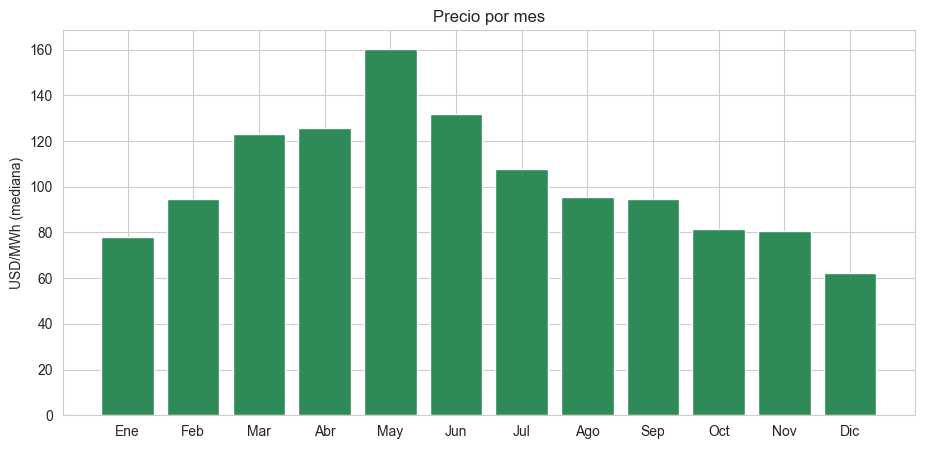

In [20]:
meses_nom = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
por_mes = train.groupby("mes")["precio"].median()

plt.bar([meses_nom[m-1] for m in por_mes.index], por_mes.values, color="seagreen")
plt.ylabel("USD/MWh (mediana)")
plt.title("Precio por mes")
plt.show()

El patrón mensual es el más marcado de los tres. De marzo a junio el precio es más alto (mayo siendo el más alto) y de julio en adelante baja, con diciembre como el mes más barato.

Esto encaja con que Guatemala depende bastante de la generación hidroeléctrica, ya que en época seca se reduce la generación de energía hidroeléctrica y el precio sube. Cuando empiezan las lluvias hay más generación, que es más barata, y el precio baja.

### Comparación entre 2023 y 2024

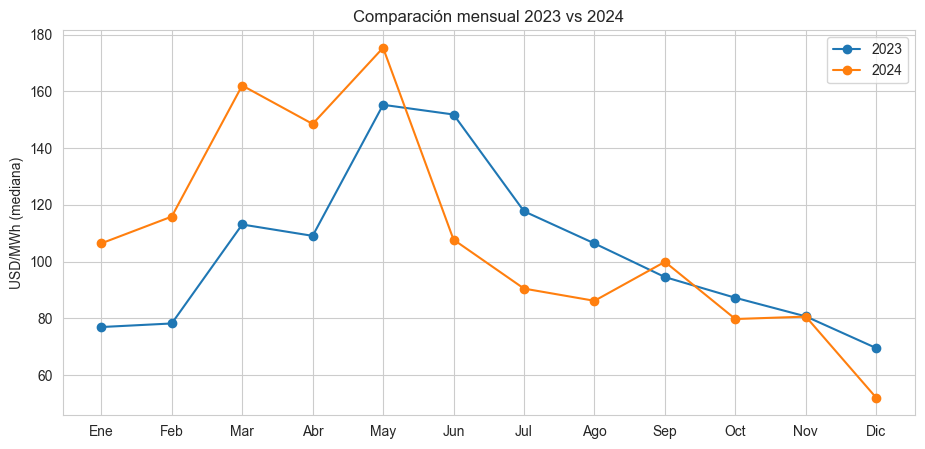

2023: mediana=104.9  máx=1376899
2024: mediana=96.4  máx=810402


In [21]:
comp = train.groupby(["anio", "mes"])["precio"].median().unstack("anio")
for a in [2023, 2024]:
    plt.plot(comp.index, comp[a], "o-", label=str(a))
plt.xticks(range(1, 13), meses_nom)
plt.ylabel("USD/MWh (mediana)")
plt.title("Comparación mensual 2023 vs 2024")
plt.legend()
plt.show()

for a in [2023, 2024]:
    s = train[train["anio"] == a]["precio"]
    print(f"{a}: mediana={s.median():.1f}  máx={s.max():.0f}")

La forma se repite en los dos años (sube en seca, baja en lluvia), lo cual conviene porque indica que hay un patrón estable que el modelo puede aprender. El nivel, en cambio, no es igual entre un año y otro. Esto sugiere que el calendario sirve para explicar la forma del precio, pero el nivel de cada año depende de factores que no están en los datos, como cuánto llovió o el precio de los combustibles.

### La distribución y los valores extremos

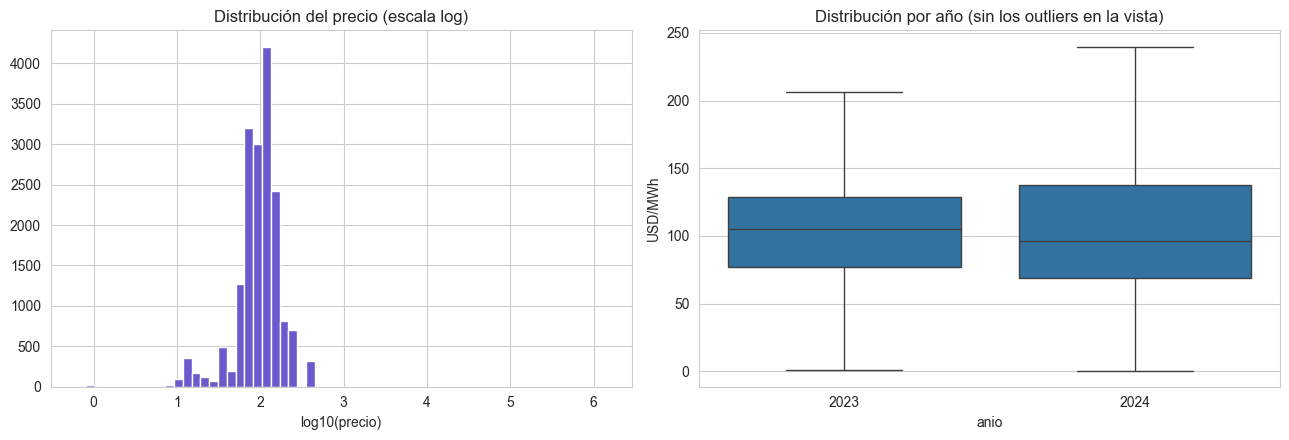

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].hist(np.log10(train["precio"].clip(lower=0.1)), bins=60, color="slateblue", edgecolor="white")
ax[0].set_xlabel("log10(precio)")
ax[0].set_title("Distribución del precio (escala log)")

sns.boxplot(data=train, x="anio", y="precio", showfliers=False, ax=ax[1])
ax[1].set_title("Distribución por año (sin los outliers en la vista)")
ax[1].set_ylabel("USD/MWh")
plt.tight_layout()
plt.show()

In [23]:
# los precios mas altos
train.nlargest(8, "precio")[["datetime", "hora", "precio"]]

,datetime,hora,precio
6329,2023-09-21 17:00:00,17,1376899.0
13703,2024-07-24 23:00:00,23,810402.0
14060,2024-08-08 20:00:00,20,172419.0
7042,2023-10-21 10:00:00,10,144388.0
6330,2023-09-21 18:00:00,18,131859.0
8996,2024-01-10 20:00:00,20,127788.0
6328,2023-09-21 16:00:00,16,117357.0
8892,2024-01-06 12:00:00,12,94444.0


La distribución está concentrada en valores bajos y tiene una cola larga hacia la derecha. Los 8 valores de arriba son mucho mayores que el resto y casi todos caen entre septiembre y octubre de 2023.

Estos valores se conservan en lugar de eliminarlos. Son precios reales que reflejan situaciones de escasez de generación. El efecto de los picos se controla en la etapa de modelado transformando el precio con log y usando el error absoluto medio (MAE) como métrica, ya que es menos sensible a los outliers.

### Mapas de calor: hora cruzada con mes y con día

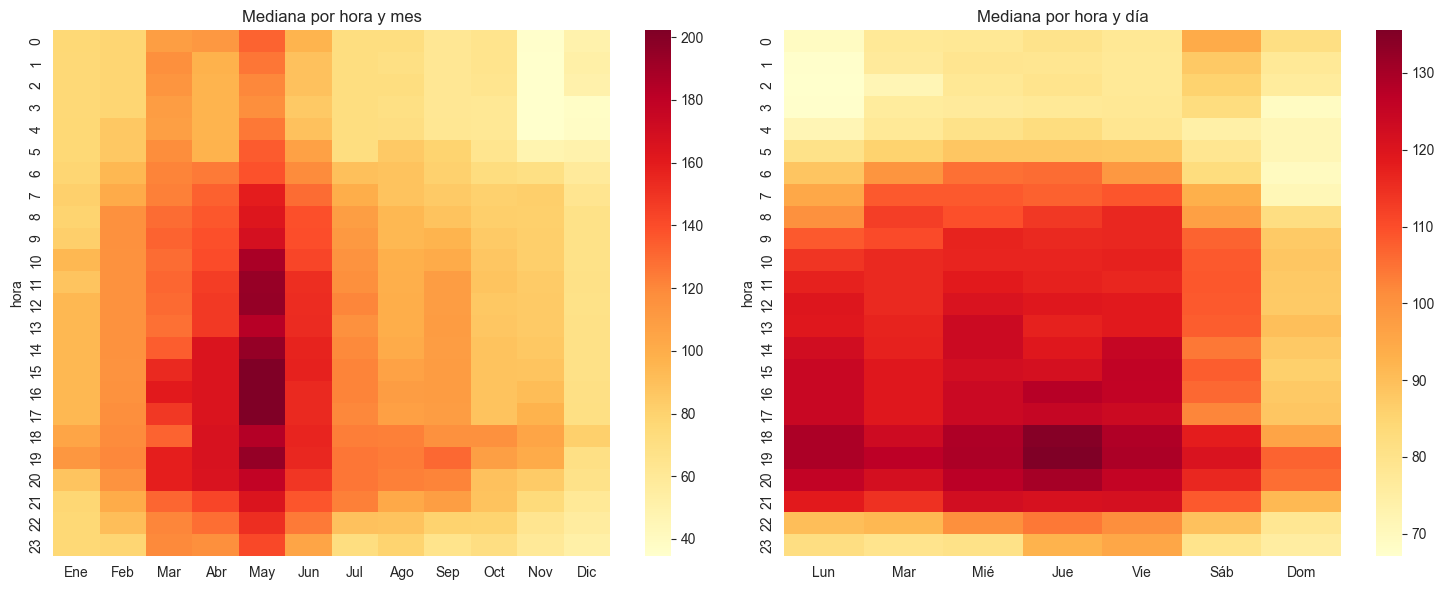

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

piv1 = train.pivot_table(index="hora", columns="mes", values="precio", aggfunc="median")
piv1.columns = [meses_nom[m-1] for m in piv1.columns]
sns.heatmap(piv1, cmap="YlOrRd", ax=ax[0])
ax[0].set_title("Mediana por hora y mes")

piv2 = train.pivot_table(index="hora", columns="dia_sem", values="precio", aggfunc="median")
piv2.columns = [dias_nom[d] for d in piv2.columns]
sns.heatmap(piv2, cmap="YlOrRd", ax=ax[1])
ax[1].set_title("Mediana por hora y día")
plt.tight_layout()
plt.show()

El primer mapa muestra que los precios más altos se dan en la tarde/noche durante la epoca seca. El segundo muestra que el patrón horario se mantiene en todos los días, aunque algo más suave el fin de semana. Entre los dos, el mes influye más en el precio que el día de la semana.

### Horas valle, intermedias y pico

Para resumir el patrón horario, las horas se agrupan en tres categorías según su precio mediano: el tercio más barato son horas valle, el del medio intermedias y el tercio más caro horas pico. 

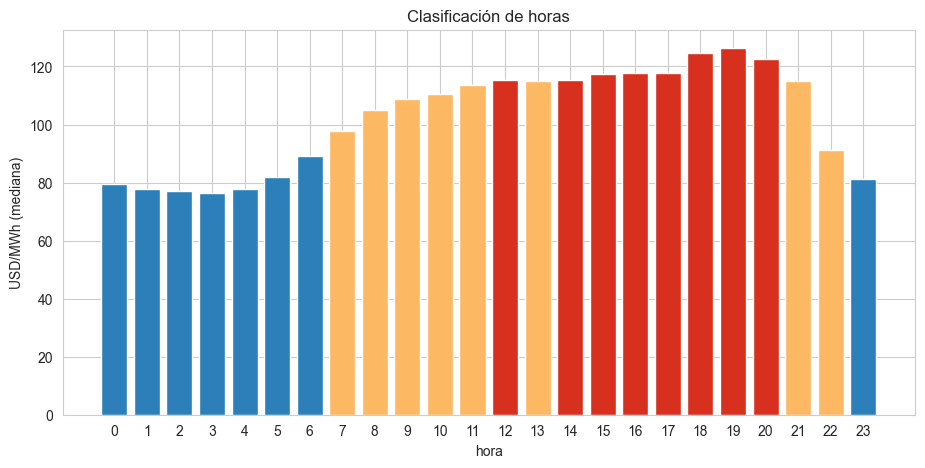

valle -> [0, 1, 2, 3, 4, 5, 6, 23]
intermedia -> [7, 8, 9, 10, 11, 13, 21, 22]
pico -> [12, 14, 15, 16, 17, 18, 19, 20]


In [25]:
mediana_hora = train.groupby("hora")["precio"].median()
c1, c2 = mediana_hora.quantile([1/3, 2/3])

def clasificar(p):
    if p <= c1: return "valle"
    if p <= c2: return "intermedia"
    return "pico"

grupo_hora = mediana_hora.apply(clasificar)

colores_g = {"valle": "#2C7FB8", "intermedia": "#FDB863", "pico": "#D7301F"}
plt.bar(mediana_hora.index, mediana_hora.values,
        color=[colores_g[grupo_hora[h]] for h in mediana_hora.index])
plt.xticks(range(24)); plt.xlabel("hora"); plt.ylabel("USD/MWh (mediana)")
plt.title("Clasificación de horas")
plt.show()

for g in ["valle", "intermedia", "pico"]:
    print(g, "->", sorted(grupo_hora[grupo_hora == g].index.tolist()))

Quedan tres bloques: las horas valle son la madrugada y las horas tarde de la noche, las pico son el mediodía y la tarde/noche, y las intermedias quedan en la transición. 

## 3. Ingeniería de Variables

A partir de lo que encontrado en el análisis exploratorio, se contruyen las siguientes variables:

- **Variables cíclicas de hora y mes** (seno/coseno): el precio depende de la hora y el mes de forma periódica. Con seno/coseno el modelo puede aprender esa periodicidad.

- **Estación**: en el EDA se observa que de marzo a junio el precio sube (época seca) y el resto del año baja (lluvias, más generación hidroeléctrica). Esta variable resume ese patrón mensual en una sola categoría.

- **Grupo de hora**: aunque se calculo anteriormente; se vuelve a calcular aquí pero **solo con datos de entrenamiento** para evitar fuga de información.

- **Precio típico por hora y por (mes, hora)**: promedios históricos (uso mediana, por la misma razón que en el inciso 2: es menos sensible a los picos extremos) calculados únicamente con el set de entrenamiento correspondiente.

- **Pico en fin de semana**: interacción entre `finde` y las horas de mayor demanda (11-21), para capturar si el efecto de "hora pico" se atenúa los fines de semana, como se observa en el heatmap.

In [26]:
df["hora_sin"] = np.sin(2*np.pi*df["hora"]/24)
df["hora_cos"] = np.cos(2*np.pi*df["hora"]/24)
df["mes_sin"]  = np.sin(2*np.pi*df["mes"]/12)
df["mes_cos"]  = np.cos(2*np.pi*df["mes"]/12)

df["estacion"] = np.where(df["mes"].between(3, 6), "seca", "lluviosa")

df["pico_finde"] = ((df["finde"]) & (df["hora"].between(11, 21))).astype(int)

train = df[df["anio"] < 2025].copy()
test_2025 = df[df["anio"] == 2025].copy()

df[["hora", "hora_sin", "hora_cos", "mes", "mes_sin", "mes_cos", "estacion", "pico_finde"]].head()

,hora,hora_sin,hora_cos,mes,mes_sin,mes_cos,estacion,pico_finde
0,0,0.000000,1.000000,1,0.5,0.866025,lluviosa,0
1,1,0.258819,0.965926,1,0.5,0.866025,lluviosa,0
2,2,0.500000,0.866025,1,0.5,0.866025,lluviosa,0
3,3,0.707107,0.707107,1,0.5,0.866025,lluviosa,0
4,4,0.866025,0.500000,1,0.5,0.866025,lluviosa,0


### Grupo de hora y promedios históricos

Estas variables sí dependen del precio, así que se define una función que reciba un set "de ajuste" (`df_fit`) para calcular los grupos y las medianas históricas, y un set "a transformar" (`df_aplicar`) donde se asignan esos valores. Así se garantiza que ninguna estadística usada como variable predictora se calculó con datos que el modelo no debería conocer todavía.

In [27]:
def agregar_variables_historicas(df_fit, df_aplicar):
    df_aplicar = df_aplicar.copy()

    # clasificando hora
    mediana_hora = df_fit.groupby("hora")["precio"].median()
    
    lim_inferior, lim_medio = mediana_hora.quantile([1/3, 2/3])
    def clasificar(p):
        if p <= lim_inferior: return "valle"
        if p <= lim_medio: return "intermedia"
        return "pico"
        
    grupo_hora = mediana_hora.apply(clasificar)
    df_aplicar["grupo_hora"] = df_aplicar["hora"].map(grupo_hora)

    # precio tipico por hora
    precio_tip_hora = df_fit.groupby("hora")["precio"].median()
    df_aplicar["precio_tip_hora"] = df_aplicar["hora"].map(precio_tip_hora)

    # precio tipico por combinacion mes-hora
    precio_tip_mes_hora = df_fit.groupby(["mes", "hora"])["precio"].median()
    df_aplicar["precio_tip_mes_hora"] = df_aplicar.set_index(["mes","hora"]).index.map(precio_tip_mes_hora).values

    return df_aplicar

### Aplicación según el esquema de validación

Como decidí entrenar con 2023 y validar con 2024, separo dos versiones de las features:

- Para **validación interna**: las estadísticas históricas se calculan solo con 2023 y se aplican tanto a 2023 (entrenamiento) como a 2024 (validación).
- Para el **modelo final**: las estadísticas se calculan con todo `train` (2023+2024) y se aplican a `train` mismo y a `test_2025`.

In [28]:
df_2023 = train[train["anio"] == 2023].copy()
df_2024 = train[train["anio"] == 2024].copy()

# para validacion interna (entrenar 2023, validar 2024
train_2023_feat = agregar_variables_historicas(df_2023, df_2023)
valid_2024_feat = agregar_variables_historicas(df_2023, df_2024)

# para el modelo final (entrenar 2023-2024, predecir 2025)
train_feat = agregar_variables_historicas(train, train)
test_2025_feat = agregar_variables_historicas(train, test_2025)

for nombre, d in [("train_2023_feat", train_2023_feat), ("valid_2024_feat", valid_2024_feat),
                   ("train_feat", train_feat), ("test_2025_feat", test_2025_feat)]:
    print(nombre, d.shape, "-", d.isna().sum().sum(), "NaNs")

train_feat[["hora","mes","estacion","grupo_hora","precio_tip_hora","precio_tip_mes_hora","pico_finde","hora_sin","mes_cos"]].head()

train_2023_feat (8760, 17) - 0 NaNs
valid_2024_feat (8784, 17) - 0 NaNs
train_feat (17544, 17) - 0 NaNs
test_2025_feat (8760, 17) - 0 NaNs


,hora,mes,estacion,grupo_hora,precio_tip_hora,precio_tip_mes_hora,pico_finde,hora_sin,mes_cos
0,0,1,lluviosa,valle,79.5145,76.72000,0,0.000000,0.866025
1,1,1,lluviosa,valle,77.6149,76.31285,0,0.258819,0.866025
2,2,1,lluviosa,valle,76.9252,76.32685,0,0.500000,0.866025
3,3,1,lluviosa,valle,76.4539,76.30085,0,0.707107,0.866025
4,4,1,lluviosa,valle,77.6556,76.72695,0,0.866025,0.866025


## 4. Preprocesamiento y Modelado

Se define el conjunto de variables predictoras (numéricas y categóricas), se construye el `ColumnTransformer` 
y se entrenan varios modelos de regresión, evaluando cada uno con el esquema de validación decidido: 
entrenar con 2023 y validar con 2024.

- **Numéricas**: las variables cíclicas (seno/coseno de hora y mes), los promedios históricos por hora 
  y por (mes, hora), y los indicadores binarios `finde`/`pico_finde`. Se escalan con `StandardScaler` 
  ya que Ridge, Lasso son sensibles a la escala.
- **Categóricas**: día de la semana, estación (seca/lluviosa) y grupo de hora (valle/intermedia/pico), 
  codificadas con `OneHotEncoder`.

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [30]:
features_num = ["hora_sin", "hora_cos", "mes_sin", "mes_cos",
                 "precio_tip_hora", "precio_tip_mes_hora",
                 "finde", "pico_finde"]
features_cat = ["dia_sem", "estacion", "grupo_hora"]
target = "precio"

X_train = train_2023_feat[features_num + features_cat]
y_train = train_2023_feat[target]
X_valid = valid_2024_feat[features_num + features_cat]
y_valid = valid_2024_feat[target]

resultados = []

def evaluar_modelo(nombre, pipe):
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_valid)
    mae = mean_absolute_error(y_valid, pred)
    rmse = root_mean_squared_error(y_valid, pred)
    r2 = r2_score(y_valid, pred)
    resultados.append({"modelo": nombre, "MAE": mae, "RMSE": rmse, "R2": r2})
    print(f"{nombre:35s} MAE={mae:7.2f}  RMSE={rmse:7.2f}  R2={r2:6.3f}")
    return pipe

preprocesador = ColumnTransformer([
    ("num", StandardScaler(), features_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), features_cat),
])

### Baseline y regresión lineal

Como baseline se utiliza un `DummyRegressor` que siempre predice el precio promedio del set de entrenamiento. Después se entrena una regresión lineal con todas las variables explicativas.

In [31]:
bl_modelo = evaluar_modelo("Baseline (media de train)", Pipeline([
    ("prep", preprocesador),
    ("modelo", DummyRegressor(strategy="mean")),
]))

lr_modelo = evaluar_modelo("Regresion lineal", Pipeline([
    ("prep", preprocesador),
    ("modelo", LinearRegression()),
]))

Baseline (media de train)           MAE= 338.67  RMSE=8999.08  R2=-0.000
Regresion lineal                    MAE= 645.79  RMSE=9020.86  R2=-0.005


### Modelo polinomial

Se aplica `PolynomialFeatures` de grado 2 sobre las variables numéricas después de escalarlas, 
para que el modelo pueda capturar relaciones no lineales e interacciones entre, por ejemplo, 
la hora del día y la época del año.

In [32]:
preprocesador_poly = ColumnTransformer([
    ("num", Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ]), features_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), features_cat),
])

poly_modelo = evaluar_modelo("Polinomial grado 2", Pipeline([
    ("prep", preprocesador_poly),
    ("modelo", LinearRegression()),
]))

Polinomial grado 2                  MAE= 896.39  RMSE=9065.60  R2=-0.015


### Modelos con regularización

Se prueba Ridge y Lasso sobre las variables originales y también combinados con 
las variables polinomiales, para ver si la regularización ayuda a controlar el posible 
sobreajuste del modelo polinomial.

In [33]:
ridge_modelo = evaluar_modelo("Ridge (alpha=1)", Pipeline([
    ("prep", preprocesador),
    ("modelo", Ridge(alpha=1.0)),
]))

lasso_modelo = evaluar_modelo("Lasso (alpha=0.1)", Pipeline([
    ("prep", preprocesador),
    ("modelo", Lasso(alpha=0.1, max_iter=10000)),
]))

poly_ridge_modelo = evaluar_modelo("Polinomial grado 2 + Ridge", Pipeline([
    ("prep", preprocesador_poly),
    ("modelo", Ridge(alpha=1.0)),
]))

poly_lasso_modelo = evaluar_modelo("Polinomial grado 2 + Lasso", Pipeline([
    ("prep", preprocesador_poly),
    ("modelo", Lasso(alpha=0.1, max_iter=10000)),
]))

Ridge (alpha=1)                     MAE= 645.58  RMSE=9020.83  R2=-0.005
Lasso (alpha=0.1)                   MAE= 645.30  RMSE=9020.81  R2=-0.005
Polinomial grado 2 + Ridge          MAE= 893.63  RMSE=9064.97  R2=-0.015
Polinomial grado 2 + Lasso          MAE= 894.63  RMSE=9065.22  R2=-0.015


c:\Users\rodri.ROBROKING\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.721e+09, tolerance: 1.951e+08
  model = cd_fast.enet_coordinate_descent(


### Variante con transformación logarítmica del precio

Tal como se planteó en el inciso 2, se aplica `log1p` al precio antes de entrenar 
(y `expm1` al predecir, para devolver las predicciones a USD/MWh). Y se utiliza `TransformedTargetRegressor`, 
que envuelve el pipeline de preprocesamiento + modelo y se encarga de la transformación/inversión 
automáticamente.

In [34]:
modelo_lr_log = evaluar_modelo("Regresion lineal (log)", TransformedTargetRegressor(
    regressor=Pipeline([
        ("prep", preprocesador),
        ("modelo", LinearRegression()),
    ]),
    func=np.log1p, inverse_func=np.expm1,
))

modelo_ridge_log = evaluar_modelo("Ridge (log)", TransformedTargetRegressor(
    regressor=Pipeline([
        ("prep", preprocesador),
        ("modelo", Ridge(alpha=1.0)),
    ]),
    func=np.log1p, inverse_func=np.expm1,
))

modelo_poly_ridge_log = evaluar_modelo("Polinomial grado 2 + Ridge (log)", TransformedTargetRegressor(
    regressor=Pipeline([
        ("prep", preprocesador_poly),
        ("modelo", Ridge(alpha=1.0)),
    ]),
    func=np.log1p, inverse_func=np.expm1,
))

Regresion lineal (log)              MAE= 177.72  RMSE=9000.25  R2=-0.000
Ridge (log)                         MAE= 177.71  RMSE=9000.25  R2=-0.000
Polinomial grado 2 + Ridge (log)    MAE= 178.25  RMSE=9000.29  R2=-0.000


### Metricas resultantes en validación

In [35]:
tabla_resultados = pd.DataFrame(resultados).sort_values("RMSE").reset_index(drop=True)
tabla_resultados

,modelo,MAE,RMSE,R2
0,Baseline (media de train),338.671705,8999.081756,-0.000046
1,Regresion lineal (log),177.715038,9000.252261,-0.000307
2,Ridge (log),177.713522,9000.252268,-0.000307
3,Polinomial grado 2 + Ridge (log),178.247344,9000.292972,-0.000316
4,Lasso (alpha=0.1),645.298808,9020.810133,-0.004881
5,Ridge (alpha=1),645.575731,9020.833858,-0.004887
6,Regresion lineal,645.786976,9020.861117,-0.004893
7,Polinomial grado 2 + Ridge,893.634871,9064.971209,-0.014744
8,Polinomial grado 2 + Lasso,894.633599,9065.224153,-0.014801
9,Polinomial grado 2,896.392526,9065.602619,-0.014886


## 5. Optimización y Comparación de Modelos


In [36]:
from sklearn.model_selection import GridSearchCV

In [37]:
modelos = {}

cv_estrategia = 5
alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0, 100000.0]

features_scale = ['precio_tip_hora', 'precio_tip_mes_hora']

encoder = OneHotEncoder(
    handle_unknown="ignore",
    drop="first",
    sparse_output=False
)

preprocesador = ColumnTransformer([
    ("num_escalado", StandardScaler(), features_scale),
    ("cat_encoded", encoder, features_cat)
], remainder="passthrough")

### Optimización de modelos
En este apartado se crean los pipelines de los modelos que se van a comparar

In [38]:
# Modelo Líneal
pipe_lineal = TransformedTargetRegressor(
    regressor=Pipeline([("prep", preprocesador), ("modelo", LinearRegression())]),
    func=np.log1p, inverse_func=np.expm1
)

pipe_lineal.fit(X_train, y_train)
modelos['Lineal'] = pipe_lineal


In [39]:
# Modelo polinomial
pipe_poly = TransformedTargetRegressor(
    regressor=Pipeline([
        ("prep", preprocesador),
        ("poly", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
        ("modelo", LinearRegression())
    ]),
    func=np.log1p, inverse_func=np.expm1
)

# Busca el mejor grado entre 2 y 3
# El grado 3 no fue opción ya que genera valores muy grandes y a consecuencia genera valores nulos
grid_poly = GridSearchCV(
    pipe_poly,
    param_grid={"regressor__poly__degree": [2]},
    cv=cv_estrategia, 
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_poly.fit(X_train, y_train)
modelos['Polinomial']=grid_poly.best_estimator_

In [40]:
#Modelos Regularizados - Ridge
pipe_ridge = TransformedTargetRegressor(
    regressor=Pipeline([("prep", preprocesador), ("modelo", Ridge())]),
    func=np.log1p, inverse_func=np.expm1
)

grid_ridge = GridSearchCV(
    pipe_ridge, 
    param_grid={"regressor__modelo__alpha": alphas}, 
    cv=cv_estrategia,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_ridge.fit(X_train, y_train)
modelos["Ridge"] = grid_ridge.best_estimator_

In [41]:
#Modelos Regularizados - Lasso
pipe_lasso = TransformedTargetRegressor(
    regressor=Pipeline([("prep", preprocesador), ("modelo", Lasso(max_iter=10000))]),
    func=np.log1p, inverse_func=np.expm1
)

grid_lasso = GridSearchCV(
    pipe_lasso, 
    param_grid={"regressor__modelo__alpha": alphas}, 
    cv=cv_estrategia, scoring="neg_mean_absolute_error", n_jobs=-1
)

grid_lasso.fit(X_train, y_train)
modelos["Lasso Optimizado"] = grid_lasso.best_estimator_

In [42]:
# Combinación polinomial + Ridge
pipe_combo = TransformedTargetRegressor(
    regressor=Pipeline([
        ("prep", preprocesador),
        ("poly", PolynomialFeatures(include_bias=False)),
        ("modelo", Ridge())
    ]),
    func=np.log1p, inverse_func=np.expm1
)

param_grid_combo = {
    "regressor__poly__degree": [2],
    "regressor__modelo__alpha": alphas
}

grid_combo = GridSearchCV(
    pipe_combo, param_grid=param_grid_combo, 
    cv=cv_estrategia, scoring="neg_mean_absolute_error", n_jobs=-1
)

grid_combo.fit(X_train, y_train)

modelos["Poly + Ridge"] = grid_combo.best_estimator_

### Evaluación de los modelos
El RMSE anterior inciso 4, nos mostraba valores muy grandes lo que nos indica que probablemnte haya valores atípicos, por lo que se ordena esta tabla por el valor MAE que nos explica en cuantas unidades se quivoca el modelo. 

In [43]:
resultados_finales = []

for nombre, modelo_entrenado in modelos.items():
    pred = modelo_entrenado.predict(X_valid)
    
    mae = mean_absolute_error(y_valid, pred)
    rmse = root_mean_squared_error(y_valid, pred)
    r2 = r2_score(y_valid, pred)
    
    resultados_finales.append({
        "Modelo": nombre, 
        "MAE": mae, 
        "RMSE": rmse, 
        "R2": r2
    })

df_comparativo = pd.DataFrame(resultados_finales).sort_values(by="MAE")
df_comparativo

,Modelo,MAE,RMSE,R2
2,Ridge,177.213551,9000.239680,-0.000304
0,Lineal,177.715038,9000.252261,-0.000307
4,Poly + Ridge,177.743572,9000.290220,-0.000315
1,Polinomial,178.024087,9000.245813,-0.000305
3,Lasso Optimizado,178.463666,9000.218205,-0.000299


In [44]:
datos_modelos = [
    {
        "Modelo": "Ridge Optimizado",
        "Hiperparámetros Ganadores": f"Alpha: {grid_ridge.best_params_['regressor__modelo__alpha']}",
        "MAE Promedio (CV)": -grid_ridge.best_score_
    },
    {
        "Modelo": "Lasso Optimizado",
        "Hiperparámetros Ganadores": f"Alpha: {grid_lasso.best_params_['regressor__modelo__alpha']}",
        "MAE Promedio (CV)": -grid_lasso.best_score_
    },
    {
        "Modelo": "Polinomial Optimizado",
        "Hiperparámetros Ganadores": f"Grado: {grid_poly.best_params_['regressor__poly__degree']}",
        "MAE Promedio (CV)": -grid_poly.best_score_
    },
    {
        "Modelo": "Combinacion Poly + Ridge",
        "Hiperparámetros Ganadores": f"Grado: {grid_combo.best_params_['regressor__poly__degree']}, Alpha: {grid_combo.best_params_['regressor__modelo__alpha']}",
        "MAE Promedio (CV)": -grid_combo.best_score_
    }
]

resultados_finales = pd.DataFrame(datos_modelos)
resultados_finales = resultados_finales.sort_values(by="MAE Promedio (CV)", ascending=True).reset_index(drop=True)

display(resultados_finales) 

,Modelo,Hiperparámetros Ganadores,MAE Promedio (CV)
0,Combinacion Poly + Ridge,"Grado: 2, Alpha: 1000.0",236.444340
1,Lasso Optimizado,Alpha: 0.01,236.692762
2,Ridge Optimizado,Alpha: 1000.0,236.715694
3,Polinomial Optimizado,Grado: 2,242.192948


Al optimizar los modelos ahora se obtiene el promedio por las particiones creadas en los hiperparametros, 
lo cual nos da una métrica más honesta, ya que evalúa al modelo bajo múltiples escenarios de volatilidad del 
mercado eléctrico. 

In [45]:
# Guardar csv para responder preguntas
modelo = modelos["Poly + Ridge"]
pipeline_interno = modelo.regressor_ if hasattr(modelo, "regressor_") else modelo

prep = pipeline_interno.named_steps["prep"]
poly = pipeline_interno.named_steps["poly"]
ridge = pipeline_interno.named_steps["modelo"] 

nombres_prep = prep.get_feature_names_out()

nombres_poly = poly.get_feature_names_out(nombres_prep)

tabla_coefs = pd.DataFrame({
    "variable": nombres_poly,
    "coeficiente": ridge.coef_,
})
tabla_coefs["abs_coef"] = tabla_coefs["coeficiente"].abs()
tabla_coefs = tabla_coefs.sort_values("abs_coef", ascending=False).drop(columns="abs_coef")

tabla_coefs.to_csv("tabla_coeficientes.csv", index=False)

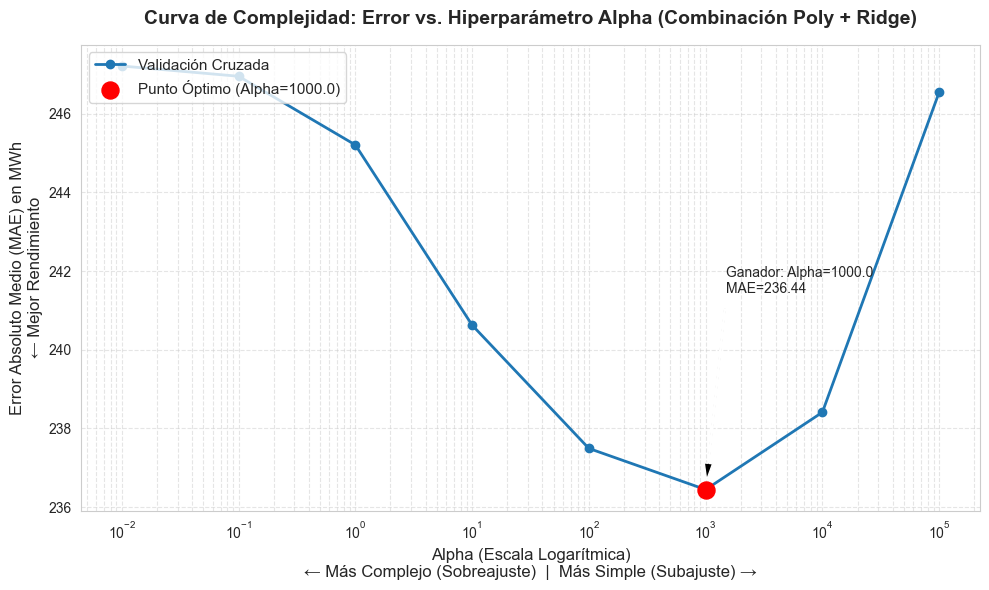

In [46]:
resultados_cv = pd.DataFrame(grid_combo.cv_results_)

alphas = resultados_cv['param_regressor__modelo__alpha'].astype(float)
mae_entrenamiento = -resultados_cv['mean_train_score'] if 'mean_train_score' in resultados_cv else None
mae_validacion = -resultados_cv['mean_test_score']

plt.figure(figsize=(10, 6))
plt.plot(alphas, mae_validacion, marker='o', linestyle='-', color='#1f77b4', linewidth=2, label='Validación Cruzada')


plt.xscale('log')
plt.title('Curva de Complejidad: Error vs. Hiperparámetro Alpha (Combinación Poly + Ridge)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Alpha (Escala Logarítmica)\n← Más Complejo (Sobreajuste)  |  Más Simple (Subajuste) →', fontsize=12)
plt.ylabel('Error Absoluto Medio (MAE) en MWh\n← Mejor Rendimiento', fontsize=12)
plt.grid(True, which="both", linestyle="--", alpha=0.5)

mejor_alpha = grid_combo.best_params_['regressor__modelo__alpha']
mejor_mae = -grid_combo.best_score_
plt.scatter(mejor_alpha, mejor_mae, color='red', s=150, zorder=5, label=f'Punto Óptimo (Alpha={mejor_alpha})')
plt.annotate(f'Ganador: Alpha={mejor_alpha}\nMAE={mejor_mae:.2f}', 
             xy=(mejor_alpha, mejor_mae), 
             xytext=(mejor_alpha * 1.5, mejor_mae + 5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()


En esta gráfica se muestra la zona de Sobreajuste. Cuando alpha es muy pequeño el modelo tienede a sesr muy complejo.

Si se siguie aumentando alpha la penalización sería severa que destruiría los coeficientes de variables clave.
El modelo ser volvería demasiado simple, lo cual aumentaría el error tanto en entrenamiento como en validación. 

El modelo ganador fue seleccionado en alpha = 1000 porque representa el mínimo global de la curva de error de 
validación cruzada. La regularización es lo suficientemente fuerte como para neutralizar la alta correlación de las 
variables estacionales y mantiene la flexibilidad necesaria para apredender la estructura real de precios del mercado
eléctrico en Guatemala. 

Ahora bien vemos que hay dos modelos que utilizan el mismo alpha en la siguiente fráfica se comparan: 

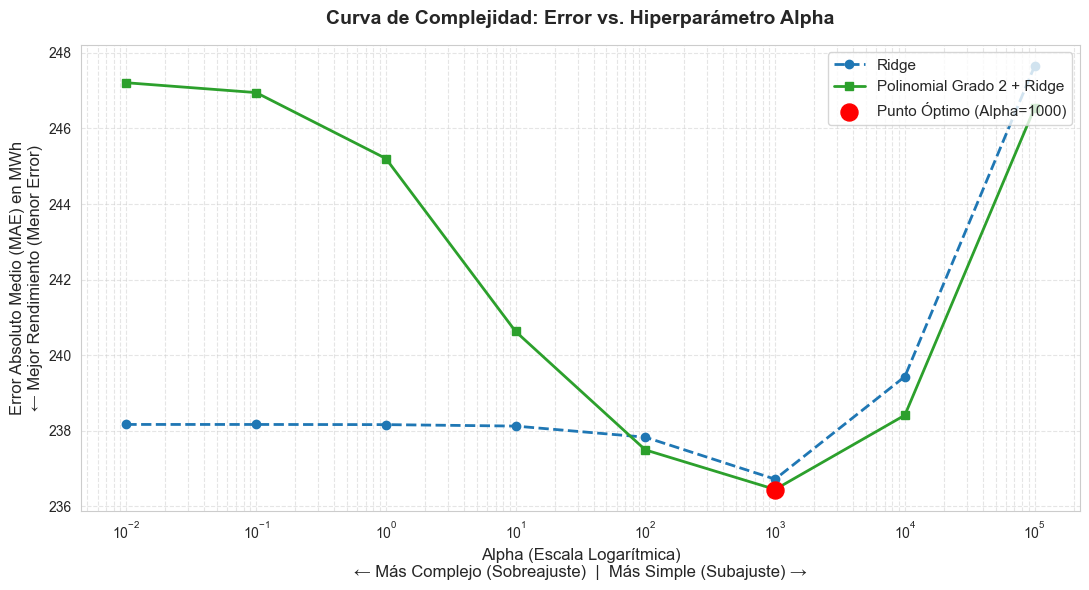

In [47]:
res_ridge = pd.DataFrame(grid_ridge.cv_results_)
res_combo = pd.DataFrame(grid_combo.cv_results_)

res_combo_grado2 = res_combo[res_combo['param_regressor__poly__degree'] == 2]

alphas_ridge = res_ridge['param_regressor__modelo__alpha'].astype(float)
mae_ridge = -res_ridge['mean_test_score']

alphas_combo = res_combo_grado2['param_regressor__modelo__alpha'].astype(float)
mae_combo = -res_combo_grado2['mean_test_score']

plt.figure(figsize=(11, 6))


plt.plot(alphas_ridge, mae_ridge, marker='o', linestyle='--', color='#1f77b4', 
         linewidth=2, label='Ridge')

plt.plot(alphas_combo, mae_combo, marker='s', linestyle='-', color='#2ca02c', 
         linewidth=2, label='Polinomial Grado 2 + Ridge')


plt.xscale('log')
plt.title('Curva de Complejidad: Error vs. Hiperparámetro Alpha', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Alpha (Escala Logarítmica)\n← Más Complejo (Sobreajuste)  |  Más Simple (Subajuste) →', fontsize=12)
plt.ylabel('Error Absoluto Medio (MAE) en MWh\n← Mejor Rendimiento (Menor Error)', fontsize=12)
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.scatter(1000.0, 236.44, color='red', s=150, zorder=5, label='Punto Óptimo (Alpha=1000)')

plt.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()


El modelo Ridge y modelo de combinación Polinomial grado 2 y Ridge utilizan el mismo alpha, pero esta curva de complejidad
comparativa demuestra el dilema de sesgo y varianza. El modelo Ridge presenta un comportamiento plano con alphas pequeños
debido a que sus variables base no inducen a sobreajuste severo, alcanzando rápidamente su límite de sesgo. 
Por el contrario la combinación de Polinomial y ridge inicia con un alto error debido a un sobreajuste provocada por las
interacciones de grado 2. al introducir una fuerte regularización (alpha = 1000), se mitiga por completo, y la curva se mantiene
debajo de la curva de Ridge. 

## 6. Evaluación Final sobre 2025

In [48]:
X_train_final = train_feat[features_num + features_cat]

y_train_final = train_feat[target]

modelo_final = grid_combo.best_estimator_

modelo_final.fit(X_train_final, y_train_final)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...pha=1000.0))])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_escalado', ...), ('cat_encoded', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense.

In [49]:
X_test_2025 = test_2025_feat[features_num + features_cat]

predicciones_2025 = modelo_final.predict(X_test_2025)

test_2025_feat['precio_predicho'] = predicciones_2025

test_2025_feat.head()

,fecha,hora,precio,anio,datetime,mes,dia_sem,finde,hora_sin,hora_cos,mes_sin,mes_cos,estacion,pico_finde,grupo_hora,precio_tip_hora,precio_tip_mes_hora,precio_predicho
17544,2025-01-01,0,17.3103,2025,2025-01-01 00:00:00,1,2,False,0.000000,1.000000,0.5,0.866025,lluviosa,0,valle,79.5145,76.72000,67.144969
17545,2025-01-01,1,17.3103,2025,2025-01-01 01:00:00,1,2,False,0.258819,0.965926,0.5,0.866025,lluviosa,0,valle,77.6149,76.31285,65.194372
17546,2025-01-01,2,17.3103,2025,2025-01-01 02:00:00,1,2,False,0.500000,0.866025,0.5,0.866025,lluviosa,0,valle,76.9252,76.32685,64.205260
17547,2025-01-01,3,17.3103,2025,2025-01-01 03:00:00,1,2,False,0.707107,0.707107,0.5,0.866025,lluviosa,0,valle,76.4539,76.30085,63.656702
17548,2025-01-01,4,2.5689,2025,2025-01-01 04:00:00,1,2,False,0.866025,0.500000,0.5,0.866025,lluviosa,0,valle,77.6556,76.72695,64.473296


### Precio real vs precio predicho

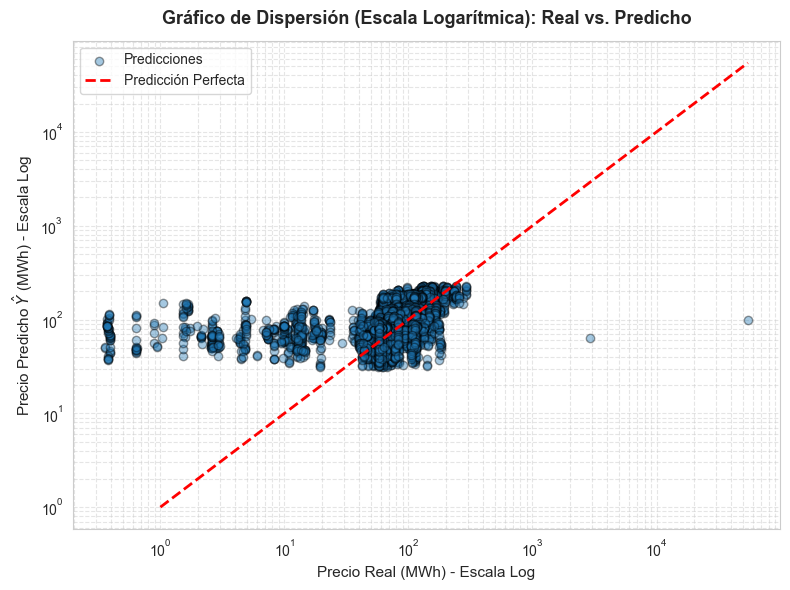

In [50]:
y_real = test_2025_feat[target]
y_pred = test_2025_feat['precio_predicho']

plt.figure(figsize=(8, 6))
plt.scatter(y_real, y_pred, alpha=0.4, color='#1f77b4', edgecolor='k', label='Predicciones')

limites = [max(1, min(y_real)), max(y_real)]
plt.plot(limites, limites, color='red', linestyle='--', linewidth=2, label='Predicción Perfecta')

plt.xscale('log')
plt.yscale('log')

plt.title('Gráfico de Dispersión (Escala Logarítmica): Real vs. Predicho', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Precio Real (MWh) - Escala Log', fontsize=11)
plt.ylabel(r'Precio Predicho $\hat{Y}$ (MWh) - Escala Log', fontsize=11)
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()


El gráfico de dispersión lineal original representaba un aplastamiento masivo deibido a un pico de precio extremo
de aproximadamente 50,000 MWh en los datos de validación. Se corrige la visualización mediante una escala logarítmica. 

Se observa que la gran mayoria de las predicciones se alinean en gran medida con la diagonal de predicción perfecta.
Sin embargo se identifica un grupo de puntos dispersos hacia el extremo izquierdo. Esto corresponde a eventos donde el
precio real de la energía cayó a niveles mínimos, mientras que el modelo estimó un precio operativo estandar. 

Esto demuestra que el modelo presenta un sesgo ligero ante caídas extremas de precios debido a que las variables
estacionales y de calendario, que tenemos actualmente, no logran capturar el movimiento de la oferta en tiempo real,
tales como picos repentinos de generación renovable (solar / eólica) o caídas súbitas en la demanda de la red. 

### Distribución de residuos

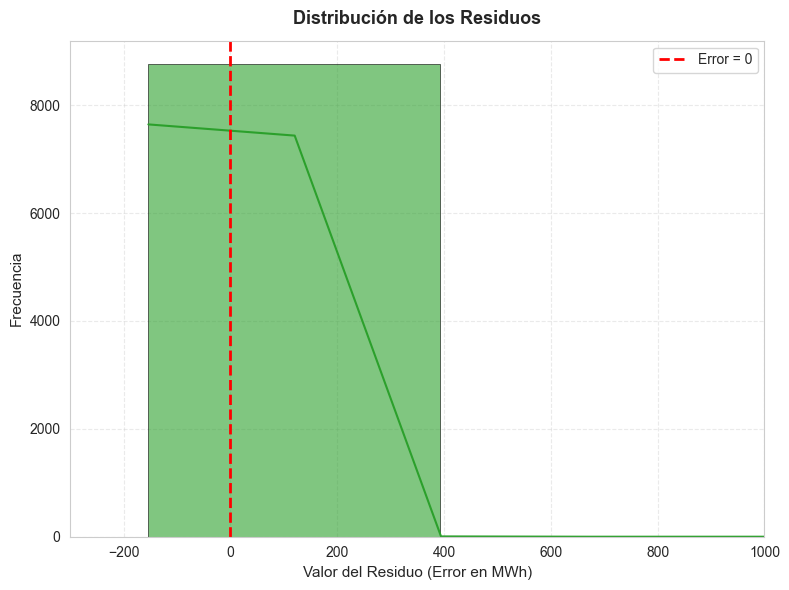

In [51]:
residuos = y_real - y_pred

plt.figure(figsize=(8, 6))

sns.histplot(residuos, kde=True, color='#2ca02c', bins=100, alpha=0.6, edgecolor='black')

plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error = 0')

plt.xlim(-300, 1000) 

plt.title('Distribución de los Residuos', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Valor del Residuo (Error en MWh)', fontsize=11)
plt.ylabel('Frecuencia', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()


El gráfico de deistribución de residuos representa una estructura asimétrica positiva con una marcada cola pesada hacía
la derecha. 

Por un lado, el rango operativo estándar (entre -200 y 400 MWh) muestra una concentración masiva que supera los
8,000 caos. Lo que vemos es que el modelo utilizado puede predicir las condiciones normales del mercado.

Por otro lado, la extensión de la curva como una línea casi plana sobre el eje X a partir de los 400MWh refleja los picos
extremos de precio. Lo que confirma que los eventos de atípicos en la red eléctrica provocan que el modelo lineal tienda
a subestimar el precio.

In [52]:
X_valid.head()

,hora_sin,hora_cos,mes_sin,mes_cos,precio_tip_hora,precio_tip_mes_hora,finde,pico_finde,dia_sem,estacion,grupo_hora
8760,0.000000,1.000000,0.5,0.866025,80.5346,76.3314,False,0,0,lluviosa,valle
8761,0.258819,0.965926,0.5,0.866025,78.0562,76.3223,False,0,0,lluviosa,valle
8762,0.500000,0.866025,0.5,0.866025,77.9441,76.5684,False,0,0,lluviosa,valle
8763,0.707107,0.707107,0.5,0.866025,77.6678,76.5684,False,0,0,lluviosa,valle
8764,0.866025,0.500000,0.5,0.866025,77.6655,76.7187,False,0,0,lluviosa,valle


### Error promedio por hora.

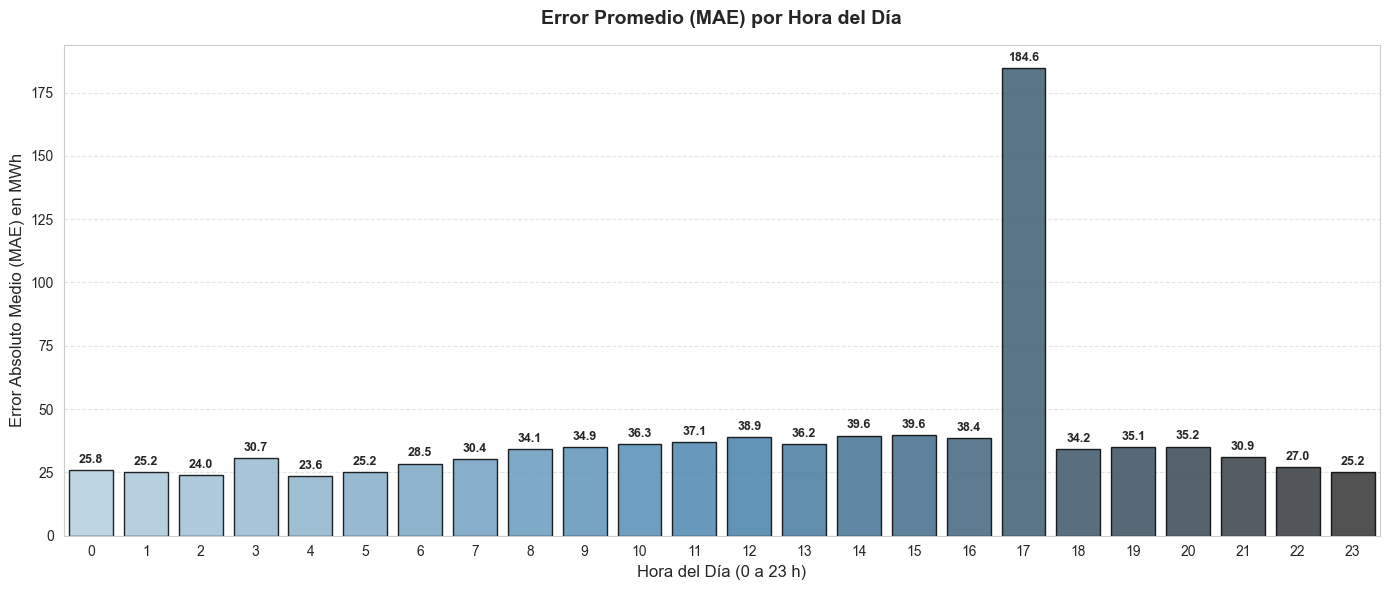

In [53]:
arr_real = np.array(y_real).flatten()
arr_pred = np.array(y_pred).flatten()
tamano_comun = len(arr_pred)

df_horas = X_valid.copy().iloc[:tamano_comun].reset_index(drop=True)

df_horas['Error_Absoluto'] = np.abs(arr_real - arr_pred)

horas_reales = np.round(np.arctan2(df_horas['hora_sin'], df_horas['hora_cos']) * (24 / (2 * np.pi))) % 24
df_horas['Hora_Exacta'] = horas_reales.astype(int)

error_por_hora_real = df_horas.groupby('Hora_Exacta')['Error_Absoluto'].mean().reset_index()

plt.figure(figsize=(14, 6))

sns.barplot(
    data=error_por_hora_real, 
    x='Hora_Exacta', 
    y='Error_Absoluto', 
    hue='Hora_Exacta',
    legend=False,
    palette='Blues_d', 
    edgecolor='black', 
    alpha=0.85
)

plt.title('Error Promedio (MAE) por Hora del Día', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hora del Día (0 a 23 h)', fontsize=12)
plt.ylabel('Error Absoluto Medio (MAE) en MWh', fontsize=12)
plt.xticks(range(24))
plt.grid(axis='y', linestyle='--', alpha=0.5)

for p in plt.gca().patches:
    height = p.get_height()
    if np.isfinite(height) and height > 0:
        plt.gca().annotate(
            f'{height:.1f}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom', fontsize=9, fontweight='bold',
            xytext=(0, 3), textcoords='offset points'
        )

plt.tight_layout()
plt.show()


El error promedio por hora mantiene un rendimiento estable durante la mayor parte del día. Se ve con facilidad 
que hay una anomalía predictiva crítica a als 17h donde el error absoluto medio se dispara. Este comportamiento
refleja la física del negocio, representa un periodo de transición hacia el pico de demanda nocturno que bien podría
ser el cese de la generación solar, ya que estos datos no los tenemos para asegurar el motivo de por que el desvío del
modelo en este bloque de horario en específico. 

# Metricas Finales


In [ ]:
y_real = test_2025_feat[target]
y_pred = test_2025_feat["precio_predicho"]

mae  = mean_absolute_error(y_real, y_pred)
rmse = root_mean_squared_error(y_real, y_pred)
r2   = r2_score(y_real, y_pred)
mediana_ae = (y_real - y_pred).abs().median()

umbral = y_real.quantile(0.99)
mask = y_real <= umbral
mae_robusto = mean_absolute_error(y_real[mask], y_pred[mask])

print("Evaluación final sobre 2025")
print(f"  MAE                        = {mae:8.2f} USD/MWh")
print(f"  RMSE                       = {rmse:8.2f} USD/MWh")
print(f"  R2                         = {r2:8.4f}")
print(f"  Mediana del error absoluto = {mediana_ae:8.2f} USD/MWh")
print(f"  MAE sin el 1% más alto     = {mae_robusto:8.2f} USD/MWh  ({(~mask).sum()} horas excluidas)")

print("\nMAE por mes:")
print((y_real - y_pred).abs().groupby(test_2025_feat["mes"]).mean().round(1).to_string())

print("\nMAE por día de la semana (0=lunes):")
print((y_real - y_pred).abs().groupby(test_2025_feat["dia_sem"]).mean().round(1).to_string())

Evaluación final sobre 2025
  MAE                        =    38.36 USD/MWh
  RMSE                       =   583.16 USD/MWh
  R2                         =  -0.0004
  Mediana del error absoluto =    25.61 USD/MWh
  MAE sin el 1% más alto     =    31.71 USD/MWh  (88 horas excluidas)

MAE por mes:
mes
1     105.2
2      21.8
3      40.9
4      36.3
5      48.2
6      59.5
7      23.0
8      19.9
9      24.0
10     23.3
11     22.7
12     33.5

MAE por día de la semana (0=lunes):
dia_sem
0    31.3
1    32.9
2    74.4
3    34.6
4    33.6
5    34.0
6    27.0


# Creación de CSV con Predicciones

In [55]:
predicciones = pd.DataFrame({
    "fecha": test_2025_feat["fecha"],
    "hora": test_2025_feat["hora"],
    "precio_real": test_2025_feat[target].round(4),
    "precio_predicho": test_2025_feat["precio_predicho"].round(2),
})
predicciones["error"] = (predicciones["precio_real"] - predicciones["precio_predicho"]).round(2)

predicciones.to_csv("predicciones_2025.csv", index=False)
print("Guardado predicciones_2025.csv ->", len(predicciones), "filas")
predicciones.head()

Guardado predicciones_2025.csv -> 8760 filas


,fecha,hora,precio_real,precio_predicho,error
17544,2025-01-01,0,17.3103,67.14,-49.83
17545,2025-01-01,1,17.3103,65.19,-47.88
17546,2025-01-01,2,17.3103,64.21,-46.90
17547,2025-01-01,3,17.3103,63.66,-46.35
17548,2025-01-01,4,2.5689,64.47,-61.90
